# Long Trace Generation for Triggering Study

This notebook generates **three long clean streams** (`ideal`, `realistic`, `stress`) with:

- fixed trace length `3276800`,
- the native DELight channel count (`56` from the current config),
- `56` designed injection points per mode,
- clean traces written to HDF5 first,
- noise generated later in a separate pass and written to separate noisy HDF5 files.

The clean and noisy outputs stay aligned because the same clean stream is reused when noise is added.

In [3]:

import h5py
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import yaml
from TraceSimulator import TraceSimulator, NoiseGenerator

def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        config_dict = yaml.safe_load(file)
    return config_dict

config = read_yaml_to_dict('/home/dwong/DELight_mtr/PCA_dev/reusable/PCA_config.yaml')
ts = TraceSimulator(config)
ng = NoiseGenerator(config)

def plot_traces(traces, fs=3_906_250, offset_step=70, title="Simulated Traceset", ax=None, show=True):
    if traces.ndim == 3 and traces.shape[0] == 1:
        traces = traces[0]

    num_channels, num_samples = traces.shape
    time_ms = np.arange(num_samples) / fs * 1000  # Time in ms

    if ax is None:
        _, ax = plt.subplots(figsize=(18, 12))

    for i in range(num_channels):
        color = 'orange' if i > 18 else 'tab:blue'
        ax.plot(time_ms, traces[i] + i * offset_step, lw=0.3, color=color)

    ax.text(0.01, 1.09, "DELight", transform=ax.transAxes, ha='left', va='top', fontsize=23, fontweight='bold', clip_on=False)
    ax.text(0.99, 1.09, "Simulation", transform=ax.transAxes, ha='right', va='top', fontsize=23, fontweight='bold', clip_on=False)

    ax.set_xlabel("Time [ms]", fontsize=16, fontweight='bold')
    ax.set_ylabel("ADC counts", fontsize=16, fontweight='bold')
    ax.set_title(title, fontsize=28, fontweight='bold')
    ax.set_xlim(0, time_ms[-1])
    ax.set_ylim(-10, offset_step * (num_channels + 1))
    ax.set_yticks([])

    if show:
        plt.tight_layout()
        plt.show()

    return ax


In [4]:
trace,(x, y, z) = ts.generate(15, type_recoil='NR', no_noise=False, quantize= False) 

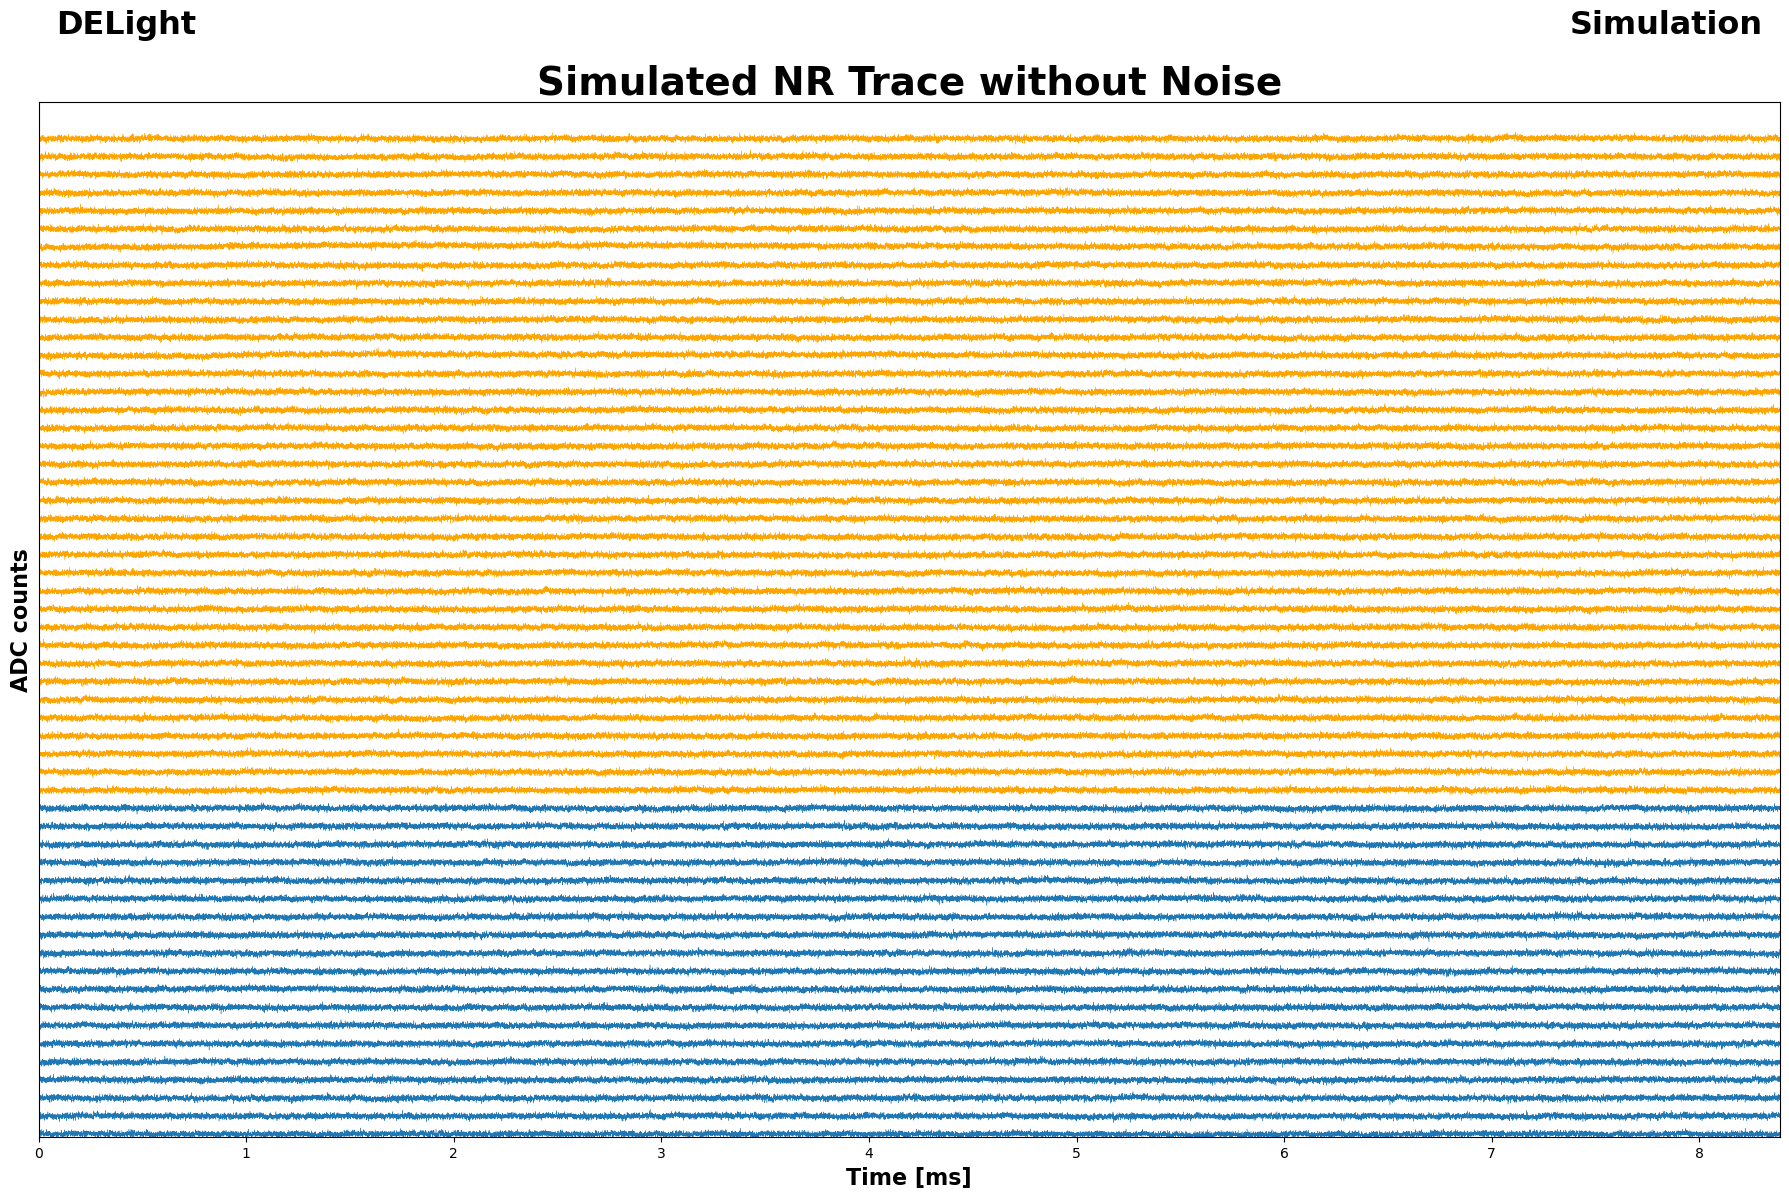

<Axes: title={'center': 'Simulated NR Trace without Noise'}, xlabel='Time [ms]', ylabel='ADC counts'>

In [5]:
plot_traces(trace, title="Simulated NR Trace without Noise")

Total channels: 56
Vacuum channels (i > 18): 37


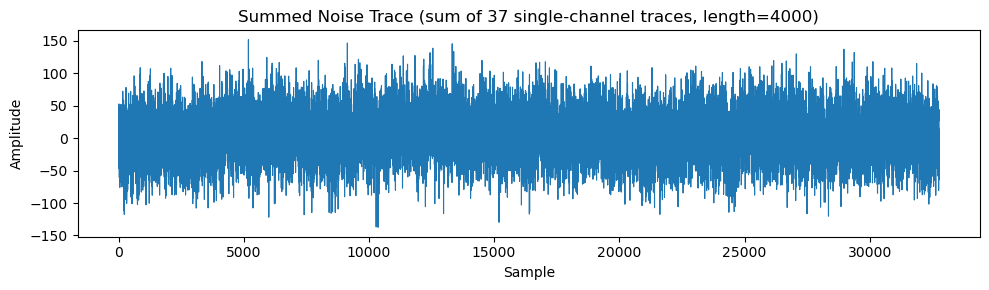

In [6]:
trace_arr = np.asarray(trace)
if trace_arr.ndim == 3 and trace_arr.shape[0] == 1:
    trace_arr = trace_arr[0]

vacuum_start = 19  # i > 18
vacuum_traces = trace_arr[vacuum_start:, :]
num_vacuum_channels = vacuum_traces.shape[0]

print(f"Total channels: {trace_arr.shape[0]}")
print(f"Vacuum channels (i > 18): {num_vacuum_channels}")

vacuum_sum = vacuum_traces.sum(axis=0)
time_ms = np.arange(vacuum_sum.shape[0]) / 3_906_250 * 1000

plt.figure(figsize=(10, 3))
plt.plot(vacuum_sum, lw=0.8)
plt.title("Summed Noise Trace (sum of 37 single-channel traces, length=4000)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()



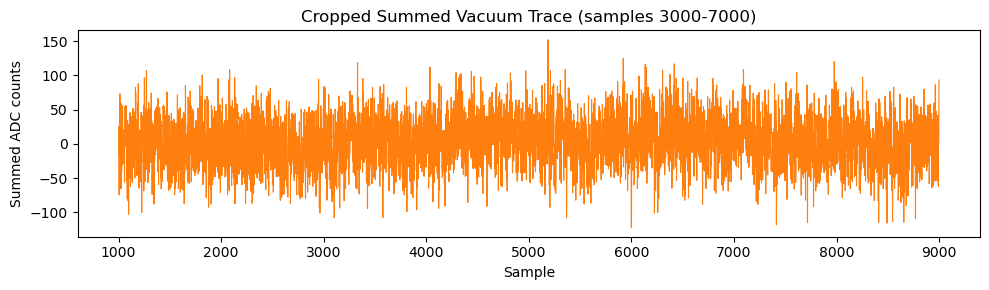

In [7]:
start_idx = 1000
end_idx = 9000

if end_idx > vacuum_sum.shape[0]:
    raise ValueError(f"Requested crop [3000:7000] exceeds trace length {vacuum_sum.shape[0]}")

vacuum_sum_crop = vacuum_sum[start_idx:end_idx]

plt.figure(figsize=(10, 3))
plt.plot(np.arange(start_idx, end_idx), vacuum_sum_crop, lw=0.8, color="tab:orange")
plt.title("Cropped Summed Vacuum Trace (samples 3000-7000)")
plt.xlabel("Sample")
plt.ylabel("Summed ADC counts")
plt.tight_layout()
plt.show()


In [8]:
# Generate 4000 traces, sum vacuum channels (i > 18), crop samples 2000:9000, save to HDF5
N_TRACES = 4000
VACUUM_START = 19  # i > 18
CROP_START = 1000
CROP_END = 9000
TYPE_RECOIL = "NR"
ENERGY = 15
OUT_PATH = Path.cwd() / "signal_vacuum_sum_crop_4000x8000.h5"

crop_len = CROP_END - CROP_START
if crop_len <= 0:
    raise ValueError("CROP_END must be greater than CROP_START")

with h5py.File(OUT_PATH, "w") as f:
    dset = f.create_dataset(
        "traces",
        shape=(N_TRACES, crop_len),
        dtype=np.float32,
        chunks=(64, crop_len),
        compression="gzip",
        compression_opts=4,
    )

    for i in range(N_TRACES):
        trace_i, _ = ts.generate(ENERGY, type_recoil=TYPE_RECOIL, no_noise=False, quantize=False)
        trace_arr = np.asarray(trace_i)
        if trace_arr.ndim == 3 and trace_arr.shape[0] == 1:
            trace_arr = trace_arr[0]

        if trace_arr.shape[1] < CROP_END:
            raise ValueError(f"Trace length {trace_arr.shape[1]} is shorter than CROP_END={CROP_END}")

        vacuum_sum = trace_arr[VACUUM_START:, :].sum(axis=0)
        dset[i] = vacuum_sum[CROP_START:CROP_END].astype(np.float32, copy=False)

        if (i + 1) % 500 == 0:
            print(f"generated {i + 1}/{N_TRACES}")

    dset.attrs["vacuum_start_index"] = int(VACUUM_START)
    dset.attrs["summed_channels"] = int(56 - VACUUM_START)
    dset.attrs["crop_start"] = int(CROP_START)
    dset.attrs["crop_end"] = int(CROP_END)
    dset.attrs["type_recoil"] = TYPE_RECOIL
    dset.attrs["energy"] = float(ENERGY)

print("Saved:", OUT_PATH)
print("Dataset: traces, shape =", (N_TRACES, crop_len), "dtype=float32")


generated 500/4000
generated 1000/4000
generated 1500/4000
generated 2000/4000
generated 2500/4000
generated 3000/4000
generated 3500/4000
generated 4000/4000
Saved: /home/dwong/DELight_mtr/PCA_dev/wk8/PC_interpretation/CNN_demo/signal_vacuum_sum_crop_4000x8000.h5
Dataset: traces, shape = (4000, 8000) dtype=float32
